# LING 498 Hackathon — Prompt 1

## Zipf in Words (Wordforms)

**Category:** Baseline Reference

**Question:** Do word tokens exhibit a Zipf-like rank–frequency distribution in a corpus slice? In other words, if we count every word in a corpus, do a few words occur extremely often while most words occur rarely?

- **Data:** NLTK Brown corpus (pick 1–2 categories: news, fiction, government, …)
- **Items to Count:** Lowercased wordforms, filtering punctuation (`regex`).

**Steps**
- Load tokens from one Brown category.
- Filter tokens that are only punctuation (`re.fullmatch(r"\W+", tok)`).
- Run `zipf_quick_report` (and zipf_plot if enabled).
- Find 2–3 high-frequency “weird” items and explain why they dominate.

**Deliverable:** Top-15 list + (optional) plot + 3-sentence interpretation.

In [1]:
import re
from nltk.corpus import brown
from nltk import FreqDist

# if NLTK Brown corpus isn't already downloaded in runtime, uncomment:
# nltk.download('brown')

In [2]:
# Helper functions
def zipf_prep(items, min_count=1):
    fd = FreqDist(items)
    # drop ultra-rare if desired
    items2 = [(k,v) for k,v in fd.items() if v >= min_count]
    items2.sort(key=lambda kv: kv[1], reverse=True)
    return items2  # list of (item, count) sorted

def zipf_quick_report(items, title="", topn=15):
    ranked = zipf_prep(items)
    print(f"\n=== {title} ===")
    print(f"Token Types: {len(ranked)} | Tokens: {sum(c for _,c in ranked)}")
    print("Top tokens:")
    for i,(k,v) in enumerate(ranked[:topn], start=1):
        print(f"{i:>2}. {str(k)[:40]:<40} {v}")
    # simple “Zipf-ness” sanity check (no regression): f1 ~ 2*f2 ~ 3*f3?
    if len(ranked) >= 5:
        f1,f2,f3,f4,f5 = [ranked[i][1] for i in range(5)]
        print("\nHeuristic ratios (closer to 1 is more Zipf-like):")
        print(" f1/(2*f2) =", round(f1/(2*f2), 3))
        print(" f1/(3*f3) =", round(f1/(3*f3), 3))
        print(" f1/(4*f4) =", round(f1/(4*f4), 3))
        print(" f1/(5*f5) =", round(f1/(5*f5), 3))
    return ranked

# Optional plotting cell (instructor can pre-enable if matplotlib is available)
def zipf_plot(ranked, n=1000, title="Top 1000 _______"):
    import matplotlib.pyplot as plt
    ranks = list(range(1, min(n, len(ranked))+1))
    freqs = [ranked[i-1][1] for i in ranks]
    plt.figure(figsize=(6,4))
    plt.loglog(ranks, freqs, marker='.')
    plt.xlabel("rank (log)")
    plt.ylabel("frequency (log)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [3]:
# Load category of choice
tokens = brown.words(categories='news')
print(f"Loaded {len(tokens)} tokens from Brown corpus category 'news'")

Loaded 100554 tokens from Brown corpus category 'news'


In [4]:
# Convert words to lowercase and remove tokens consisting only of punctuation
words = [
    token.lower()
    for token in tokens
    if not re.fullmatch(r"\W+", token) 
]
print(words[:10])

['the', 'fulton', 'county', 'grand', 'jury', 'said', 'friday', 'an', 'investigation', 'of']



=== Brown Corpus: News Wordforms ===
Token Types: 13099 | Tokens: 88592
Top tokens:
 1. the                                      6386
 2. of                                       2861
 3. and                                      2186
 4. to                                       2144
 5. a                                        2130
 6. in                                       2020
 7. for                                      969
 8. that                                     829
 9. is                                       733
10. was                                      717
11. on                                       691
12. he                                       642
13. at                                       636
14. with                                     567
15. be                                       526

Heuristic ratios (closer to 1 is more Zipf-like):
 f1/(2*f2) = 1.116
 f1/(3*f3) = 0.974
 f1/(4*f4) = 0.745
 f1/(5*f5) = 0.6


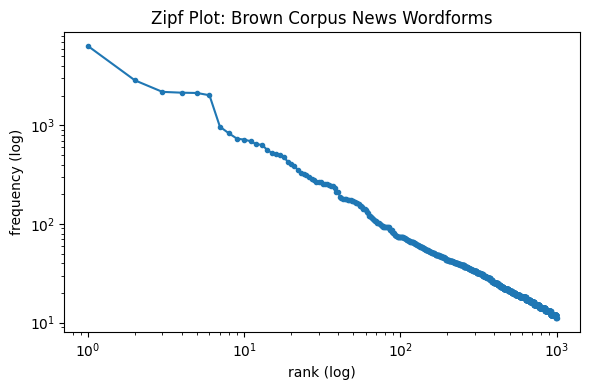

In [5]:
ranked = zipf_prep(words)
zipf_quick_report(words, title="Brown Corpus: News Wordforms")
zipf_plot(ranked, title="Zipf Plot: Brown Corpus News Wordforms")

### Interpretation

The distribution of wordforms follows a Zipf-like pattern: a small number of words occur very frequently, while most wordforms appear only a few times. Function words such as `the`, `of`, and `and` appear at the top of the list because they are used in many different grammatical contexts. In contrast, most content words appear less often because they are used in more specific topics or situations. For example, words such as `microscope` or `hurricane` are only likely to appear when those topics are being discussed. Overall, the rank–frequency curve shows that English uses a small group of very common words repeatedly, while the majority of words occur much less frequently.

**Deviation Prompts:**
- What preprocessing choice most affects the curve?

Lowercasing has the greatest effect because it merges capitalized and lowercase versions of the same word (for example, `The` and `the`), reducing the number of distinct word types and increasing the frequency of the merged forms.

- One spike or oddity: linguistic cause or methodological artifact?

The very high frequency of function words such as `the`, `of`, and `and` is primarily a linguistic phenomenon, since these words are essential for English grammar and appear in nearly every text.

- What alternative “unit” would change results (lemma, POS, etc.)?

Using lemmas instead of wordforms would merge inflected forms such as `run`, `runs`, `running`, and `ran` into a single unit, producing fewer types and changing the overall frequency distribution. Other alternatives, such as POS tags or morphemes, would produce different Zipf curves because they measure different linguistic units.